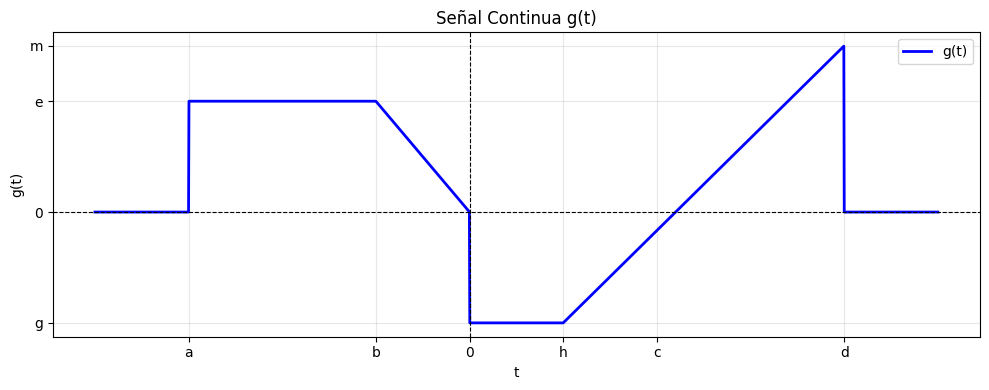

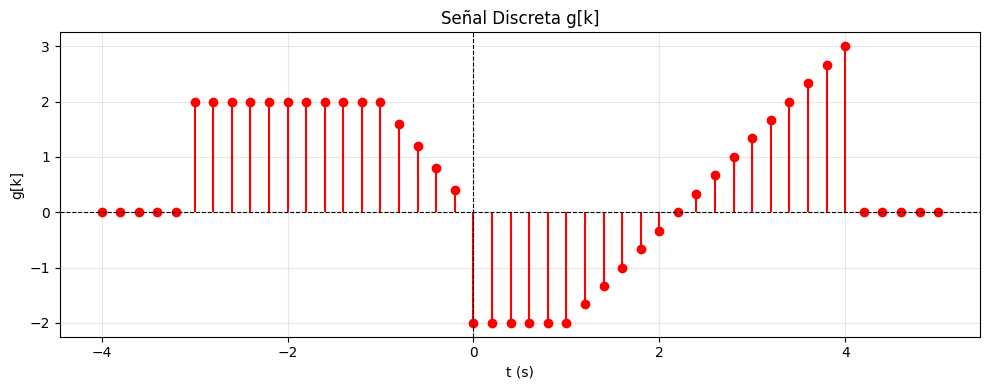

Índices de inflexión (máximo entero):
- En t = a (-3s): k = -15
- En t = b (-1s): k = -5
- En t = 0 (0.0s): k = 0
- En t = h (1s): k = 5
- En t = c (2s): k = 10
- En t = d (4s): k = 20


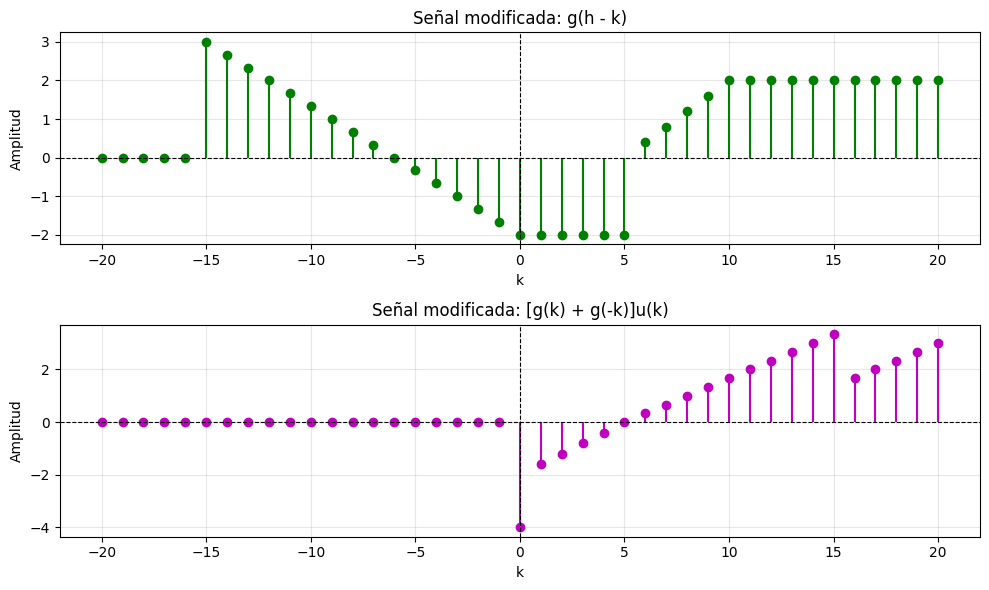

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros según la estructura correcta de la imagen
a, b, h, c, d = -3, -1, 1, 2, 4
e, g_val, m = 2, -2, 3

# Rango temporal continuo
t = np.linspace(a - 1, d + 1, 2000)

def g_continua(t_val):
    g = np.zeros_like(t_val)
    for i, ti in enumerate(t_val):
        if a <= ti < b:
            g[i] = e
        elif b <= ti < 0:
            # Rampa descendente desde (b, e) hasta el origen (0, 0)
            g[i] = e + (0 - e) * (ti - b) / (0 - b)
        elif 0 <= ti <= h:
            # Tramo constante en el nivel g desde t=0 hasta t=h
            g[i] = g_val
        elif h < ti <= d:
            # Rampa ascendente desde (h, g) hasta (d, m), cruzando el eje en c
            g[i] = g_val + (m - g_val) * (ti - h) / (d - h)
        else:
            g[i] = 0
    return g

# Representación exacta con plt.plot()
plt.figure(figsize=(10, 4))
plt.plot(t, g_continua(t), 'b-', linewidth=2, label='g(t)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xticks([a, b, 0, h, c, d], ['a', 'b', '0', 'h', 'c', 'd'])
plt.yticks([g_val, 0, e, m], ['g', '0', 'e', 'm'])
plt.title('Señal Continua g(t)')
plt.xlabel('t')
plt.ylabel('g(t)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show

# Bloque para implementar y graficar la señal discreta g[k]
k_min = int(np.floor((a - 1) / Ts))
k_max = int(np.floor((d + 1) / Ts))
k = np.arange(k_min, k_max + 1)
tk = k * Ts
gk = g_continua(tk)

plt.figure(figsize=(10, 4))
plt.stem(tk, gk, linefmt='r-', markerfmt='ro', basefmt=' ')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Señal Discreta g[k]')
plt.xlabel('t (s)')
plt.ylabel('g[k]')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cálculo y visualización de los índices de inflexión utilizando la función de máximo entero (np.floor)
puntos_inflexion = {'a': a, 'b': b, '0': 0.0, 'h': h, 'c': c, 'd': d}

print("Índices de inflexión (máximo entero):")
for nombre, val in puntos_inflexion.items():
    k_idx = int(np.floor(val / Ts))
    print(f"- En t = {nombre} ({val}s): k = {k_idx}")

# Rango de índices discretos para evaluar las operaciones
k_indices = np.arange(-20, 21)

# 1. Señal modificada: g(h - k)
# Evaluamos la señal continua usando el argumento desplazado y reflejado (h - k*Ts)
g_h_minus_k = g_continua(h - k_indices * Ts)

# 2. Señal combinada: [g(k) + g(-k)] u(k)
g_k = g_continua(k_indices * Ts)
g_minus_k = g_continua(-k_indices * Ts)
u_k = np.heaviside(k_indices, 1)  # Escalón unitario u(k)
comb_signal = (g_k + g_minus_k) * u_k

# Gráficas de ambas señales en una misma figura con dos subgráficas
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

ax1.stem(k_indices, g_h_minus_k, linefmt='g-', markerfmt='go', basefmt=' ')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('Señal modificada: g(h - k)')
ax1.set_xlabel('k')
ax1.set_ylabel('Amplitud')
ax1.grid(True, alpha=0.3)

ax2.stem(k_indices, comb_signal, linefmt='m-', markerfmt='mo', basefmt=' ')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Señal modificada: [g(k) + g(-k)]u(k)')
ax2.set_xlabel('k')
ax2.set_ylabel('Amplitud')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

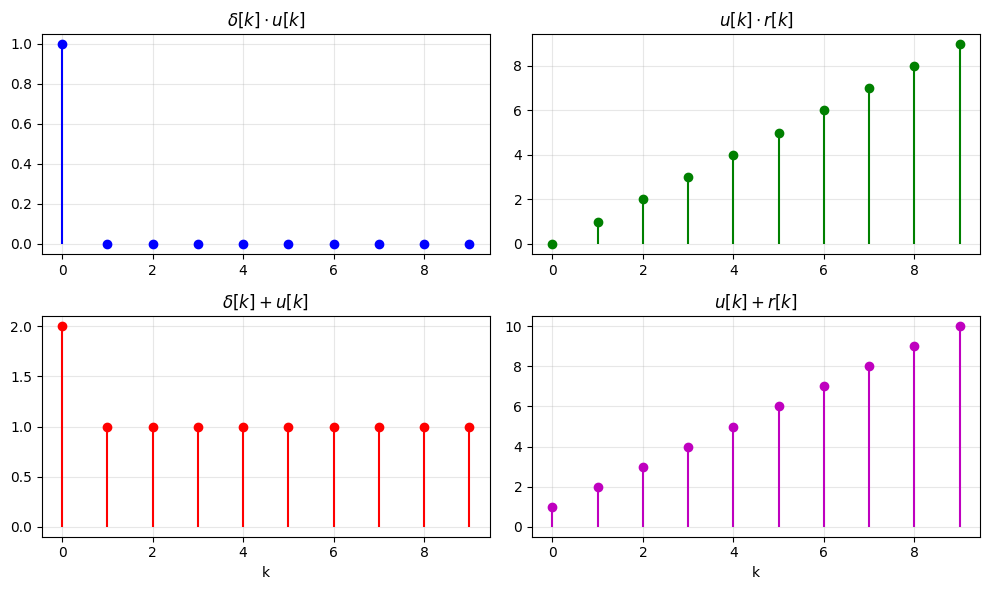

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Ventana de 10 muestras (k de 0 a 9)
k = np.arange(0, 10)

# Construcción de las secuencias básicas usando NumPy
delta = (k == 0).astype(float)        # Impulso delta[k]
u = np.ones_like(k, dtype=float)      # Escalón u[k]
r = k.astype(float)                   # Rampa r[k]

# Cálculo de las cuatro operaciones muestra a muestra
op1 = delta * u
op2 = u * r
op3 = delta + u
op4 = u + r

# Representación gráfica con plt.stem() en una figura de 2x2 subgráficas
fig, axs = plt.subplots(2, 2, figsize=(10, 6))

axs[0, 0].stem(k, op1, linefmt='b-', markerfmt='bo', basefmt=' ')
axs[0, 0].set_title(r'$\delta[k] \cdot u[k]$')
axs[0, 0].grid(True, alpha=0.3)

axs[0, 1].stem(k, op2, linefmt='g-', markerfmt='go', basefmt=' ')
axs[0, 1].set_title(r'$u[k] \cdot r[k]$')
axs[0, 1].grid(True, alpha=0.3)

axs[1, 0].stem(k, op3, linefmt='r-', markerfmt='ro', basefmt=' ')
axs[1, 0].set_title(r'$\delta[k] + u[k]$')
axs[1, 0].set_xlabel('k')
axs[1, 0].grid(True, alpha=0.3)

axs[1, 1].stem(k, op4, linefmt='m-', markerfmt='mo', basefmt=' ')
axs[1, 1].set_title(r'$u[k] + r[k]$')
axs[1, 1].set_xlabel('k')
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

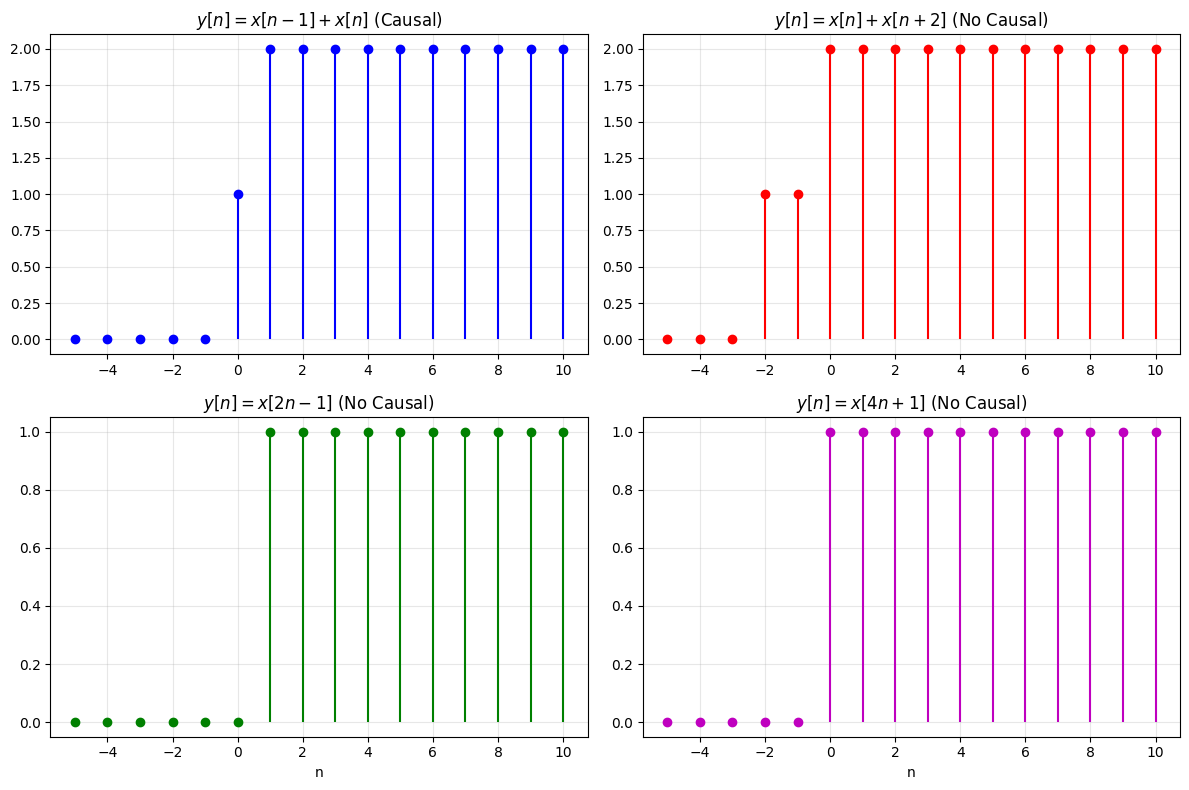

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Definir el rango de índices n para la visualización
n = np.arange(-5, 11)

# Rango extendido para evaluar de forma segura índices futuros o escalados (x[n+2], x[2n-1], etc.)
n_extended = np.arange(-10, 50)
# Usamos una señal de entrada de ejemplo, por ejemplo, el escalón unitario u[n]
x_ext = (n_extended >= 0).astype(float)

def get_x(idx):
    """Función auxiliar para obtener x[idx] manejando ceros fuera del rango definido."""
    res = np.zeros_like(idx, dtype=float)
    for i, val in enumerate(idx):
        mask = (n_extended == val)
        if np.any(mask):
            res[i] = x_ext[mask][0]
    return res

# 1. y[n] = x[n-1] + x[n] (Causal)
y1 = get_x(n - 1) + get_x(n)

# 2. y[n] = x[n] + x[n+2] (No causal - depende de un valor futuro n+2)
y2 = get_x(n) + get_x(n + 2)

# 3. y[n] = x[2n-1] (No causal - depende de valores futuros para n >= 1)
y3 = get_x(2 * n - 1)

# 4. y[n] = x[4n+1] (No causal - depende de valores futuros para n >= 0)
y4 = get_x(4 * n + 1)

# Representación gráfica en una malla de 2x2 subgráficas
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].stem(n, y1, linefmt='b-', markerfmt='bo', basefmt=' ')
axs[0, 0].set_title(r'$y[n] = x[n-1] + x[n]$ (Causal)')
axs[0, 0].grid(True, alpha=0.3)

axs[0, 1].stem(n, y2, linefmt='r-', markerfmt='ro', basefmt=' ')
axs[0, 1].set_title(r'$y[n] = x[n] + x[n+2]$ (No Causal)')
axs[0, 1].grid(True, alpha=0.3)

axs[1, 0].stem(n, y3, linefmt='g-', markerfmt='go', basefmt=' ')
axs[1, 0].set_title(r'$y[n] = x[2n-1]$ (No Causal)')
axs[1, 0].set_xlabel('n')
axs[1, 0].grid(True, alpha=0.3)

axs[1, 1].stem(n, y4, linefmt='m-', markerfmt='mo', basefmt=' ')
axs[1, 1].set_title(r'$y[n] = x[4n+1]$ (No Causal)')
axs[1, 1].set_xlabel('n')
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
import numpy as np

# Secuencias de prueba
n = np.arange(0, 15)
x1 = np.sin(n * 0.5)
x2 = np.cos(n * 0.5)
a, b = 2.0, 3.0
x_comb = a * x1 + b * x2

# Definición de los 4 sistemas
def sys1(x): return 4 * x + 1
def sys2(x): return x**2
def sys3(x, idx):
    # Simulación de desplazamientos usando un vector extendido para evitar desbordamientos
    res = np.zeros_like(x)
    for i, val in enumerate(idx):
        # x[n-2] y x[n-8]
        val_minus_2 = x[i-2] if i-2 >= 0 else 0
        val_minus_8 = x[i-8] if i-8 >= 0 else 0
        res[i] = val_minus_2 - 2 * val_minus_8
    return res

def sys4(x, idx):
    res = np.zeros_like(x)
    for i, val in enumerate(idx):
        target_idx = 4 * val + 1
        if 0 <= target_idx < len(x):
            res[i] = x[target_idx]
        else:
            res[i] = 0
    return res

# Verificación numérica (Superposición: T[a*x1 + b*x2] vs a*T[x1] + b*T[x2])
print("Verificación de Linealidad (Diferencia máxima esperada 0 para sistemas lineales):")
print(f"1. y[n] = 4x[n] + 1 -> Max Diff: {np.max(np.abs(sys1(x_comb) - (a * sys1(x1) + b * sys1(x2))))}")
print(f"2. y[n] = x^2[n]      -> Max Diff: {np.max(np.abs(sys2(x_comb) - (a * sys2(x1) + b * sys2(x2))))}")
print(f"3. y[n] = x[n-2]-2x[n-8] -> Max Diff: {np.max(np.abs(sys3(x_comb, n) - (a * sys3(x1, n) + b * sys3(x2, n))))}")
print(f"4. y[n] = x[4n+1]    -> Max Diff: {np.max(np.abs(sys4(x_comb, n) - (a * sys4(x1, n) + b * sys4(x2, n))))}")

Verificación de Linealidad (Diferencia máxima esperada 0 para sistemas lineales):
1. y[n] = 4x[n] + 1 -> Max Diff: 4.000000000000002
2. y[n] = x^2[n]      -> Max Diff: 10.217118570584887
3. y[n] = x[n-2]-2x[n-8] -> Max Diff: 2.6645352591003757e-15
4. y[n] = x[4n+1]    -> Max Diff: 0.0
